In [ ]:
import os, sys
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import scipy.io as sio

%load_ext autoreload
%autoreload 2

sys.path.append('.')
from Wen_data_test.Wen_utils import load_maps, spectral_analysis, convert_raw_data
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr, plot_toroidal_coordinates
from toroidal_coordinates.Gardner_toroidal import Gardner_coord, Gardner_persistence
from ripser import ripser# type: ignore
from constants import GIOCOMO_DATA_PATH
import math
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance_upgrade
from affine_transform.get_transform_mat import *
from affine_transform.score_mismatch import *
from Campbell_data_test.Campbell_utils import *

In [ ]:
data_dir = GIOCOMO_DATA_PATH


In [30]:
ind_fis = {}
ind_fis['npI1_0417'] = ((1,(0,1,2)),
                        (4,(0,1,2)),
                        (5,(0,1,2)),)

ind_fis['npG2_1211'] = ((4,(0,)),)
ind_fis['npH1_0314'] = ((1,(1,)),)
ind_fis['npH3_0402'] = ((1,(0,1)),)
ind_fis['npI1_0414'] = ((0,(0,)), 
                         (1,(0,1)),)
ind_fis['npI1_0416'] = ((1,(1,)),)
ind_fis['npI5_0414'] = ((0,(1,)),
                         (3,(0,)))

ind_fis['npI5_0415'] = ((0,(2,)),)

ind_fis['npJ1_0521'] = ((2,(1,)),)
ind_fis['npJ1_0524'] = ((3,(1,2)),)
ind_fis['npJ5_0505'] = ((0,(0,1,2)),)
ind_fis['npJ5_0506'] = ((2,(0,1)),
                        (3,(0,)),
                        (4,(0,1)),
                        (5,(0,)),
                       )
ind_fis['npJ5_0507'] = ((0,(0,1)),)


In [31]:
count1 = 0

k = 1000          # number of neighbours for downsampling
dt_curr = 0.01    # time bin interval
time_resolution = 100000 
sigma = 10
thr = 0.46
sp = 10
dim = 7
eps = 0.7
nn = 1
n_points = 1200
thrstr = str(int(thr*100))    
maxdim = 1
dt_curr = 0.01
time_resolution = 100000
min_time = 0
bCont = True

In [45]:
mouse_sess = 'npI5_0415'

In [46]:
if mouse_sess == 'npH3_0402':
    bCont = False
if bCont:
    raise Exception
    
mouse_folder = 'Results/' + mouse_sess
try:
    os.mkdir(mouse_folder)
except:
    print('Folder exists')
files = glob.glob(data_dir + '/' + mouse_sess + '_*.mat')
files.sort()
print(files)

Folder exists
['/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_baseline_1.mat', '/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_dark_1.mat', '/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_gain_1.mat']


In [47]:
cells_inds = {}
indskeep_all = {}
offsets = {}
xcoords = {}
ycoords = {}
vr_session_offset = {}
spike_depth = {}
depth = {}
regions = {}
for fi in files:
    data = loadmat(fi)
    if 'anatomy' in list(data.keys()):
        anatomy = data['anatomy']
        if 'parent_shifted' in anatomy:
            group = anatomy['parent_shifted']
        else:
            group = anatomy['cluster_parent']
        depth[fi] = data['anatomy']['tip_distance']
    else:
        group = np.array(['MEC' for n in range(len(data['sp']['cids']))])
        depth[fi] = np.array([0 for n in range(len(data['sp']['cids']))])
    cells_inds[fi] = data['sp']['cids']
    regions[fi] = group
    xcoords[fi] = data['sp']['xcoords']
    ycoords[fi] = data['sp']['ycoords']
    indskeep_all[fi]  = data['sp']['cgs']

In [48]:
data_trials = {}
data_pos = {}
sspk1 = {}
spk_count1 = {}
speed = {}
posx = {}
post = {}
posxx = {}
postt = {}
postrial = {}
gain = {}
contrast = {}
lickt = {}
lickx = {}
spike_times = {}

max_times = {}

In [49]:
for fi in files[:]:
    data = loadmat(fi)
    spikes = {}
    for cell_idx in range(len(cells_inds[fi])):   
        spikes[cell_idx] = data['sp']['st'][data['sp']['clu'] == cells_inds[fi][cell_idx]]    
    spike_times[fi] = spikes.copy()

    max_time = data['sp']['st'].max()+dt_curr
    max_times[fi] = max_time.copy()
    spk_count1[fi], tt = spk_count(spikes, min_time = min_time, max_time = max_time, dt_orig = dt_curr, res = time_resolution)
    sspk1[fi], __ = firing_rate(spikes, sigma = sigma/10, min_time = min_time, max_time = max_time, 
                                dt_orig = dt_curr*10, res = time_resolution/10)

    data = loadmat(fi)

    max_time = data['sp']['st'].max() +dt_curr
    max_times[fi] = max_time.copy()

    xtmp = data['posx'].copy()
    xtmp += (data['trial']-1)*400


    postt[fi], posxx[fi], __, speed[fi],__ = get_pos1(xtmp, [], data['post'], [],
                                                        dt_curr, res = time_resolution, min_time = min_time, max_time = max_time)
    posxx[fi] = posxx[fi]%400

    postrial[fi] = data['trial']
    gain[fi] = data['trial_gain']
    contrast[fi] = data['trial_contrast']
    lickt[fi] = data['lickt']        
    lickx[fi] = data['lickx']
    tt_dig = np.digitize(postt[fi], data['post'])-1    
    postrial[fi] = data['trial'][tt_dig]
    data_trials[fi] = np.unique(data['trial'])

In [50]:
indskeep = np.ones(len(indskeep_all[files[0]]), dtype = bool)
for ii in indskeep_all:
    if len(indskeep) != len(indskeep_all[ii]):
        continue
    indskeep[~indskeep | ~(indskeep_all[ii]==2)] = False  
indsreg = np.ones(len(regions[files[0]]), dtype = bool)
for ii in regions:
    if len(indsreg) != len(regions[ii]):
        continue
    indsreg[~indsreg | ~(regions[ii]=='MEC')] = False 
num_neurons = len(spk_count1[files[0]][0,:])
indsnull = np.ones(num_neurons,dtype =bool)
meanRate = {}
for fi in spk_count1:
    spksum = np.sum(spk_count1[fi], 0)/len(spk_count1[fi])*100
    indsnull[(spksum<0.05) | (spksum>10)] = False
    meanRate[fi] = spksum.copy()

/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/utils_new.py:4466: RuntimeWarning: invalid value encountered in scalar divide
  crosscorrs1[i1,j1] =  (np.min(c)/np.max(c))


0.24222278594970703


/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/utils_new.py:6020: RuntimeWarning: invalid value encountered in divide
  acorrs[i,:] /= acorrs[i,0]


5.330150127410889
0.3092160224914551
5.083130836486816
0.5537090301513672
10.156976222991943
/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_baseline_1.mat


/var/folders/g9/g_yqzs1x1zq8rs_nz29_2cy00000gn/T/ipykernel_66166/1458199522.py:17: RuntimeWarning: invalid value encountered in divide
  t_acorr[i,:] = t_acorr[i,:]/t_acorr[i,0]


/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_dark_1.mat
/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_gain_1.mat


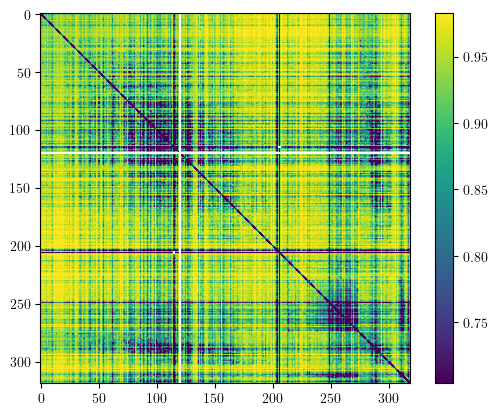

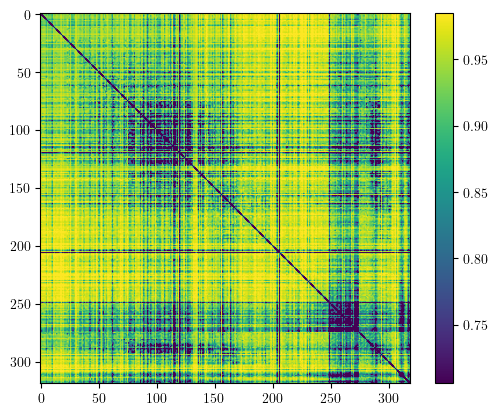

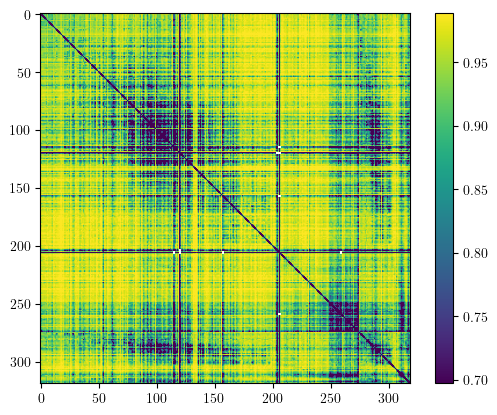

In [51]:
if len(glob.glob('Results/' + mouse_sess + '_corrs.npz')) ==0:
    num_neurons = len(sspk1[files[0]][0,:])
    Xcorr = {}
    for fi in files:
        sspikes = np.sqrt(sspk1[fi])
        t0 = time.time()
        Xcorr[fi] =  cross_corr_dist(sspikes, lencorr = 30)
    acorrs = get_acorr(mouse_sess, good_cells = np.arange(num_neurons), data_trials = data_trials,
                        sspk1 = spk_count1, files = files, posxx = posxx, postrial = postrial)
    t_acorrs = {}
    for fi in files:
        print(fi)
        t_acorr = get_temporal_acorr(spike_times[fi], maxspikes = 1000, inds = np.where(indsnull)[0])
        t_acorr = t_acorr[:, 200:]
        t_acorr = t_acorr.astype(float)
        for i in range(len(t_acorr[:,0])):
            t_acorr[i,:] = t_acorr[i,:]/t_acorr[i,0]
        t_acorr[:,0] = 0
        t_acorr = gaussian_filter1d(t_acorr[:, :],sigma = 2, axis = 1)
        t_acorrs[fi] = t_acorr.copy()
    # np.savez('Results/' + mouse_sess + '_corrs', 
    #             acorr = acorrs, 
    #             t_acorr = t_acorrs, 
    #             Xcorr = Xcorr)
else:
    pass
    # f = np.load('Results/' + mouse_sess + '_corrs.npz', allow_pickle = True) 
    # acorrs = f['acorr'][()]
    # t_acorrs = f['t_acorr'][()]
    # Xcorr = f['Xcorr'][()]
    # f.close()

In [52]:
num_neurons = len(Xcorr[files[0]])
indskeep_bu = np.where(indsnull & indskeep )[0]#np.arange(num_neurons)
d1 = np.zeros((len(indskeep_bu),len(indskeep_bu)))
for x in Xcorr:    
    xtmp = Xcorr[x]
    xtmp = xtmp[indskeep_bu,:]
    xtmp = xtmp[:, indskeep_bu]
    dd1 = squareform(pdist(np.square(xtmp), 'correlation'))
    d1 += dd1
infs = np.isinf(d1)
d1[infs] = np.max(d1[~infs])*2
d1 /= len(Xcorr)
dvals = d1[np.triu_indices(len(d1),1)]

ind1 = get_ind(d1,thr, linkage = 'average', bPlot = False)
numinds = np.bincount(ind1)
rel_inds = np.where((ind1>=19) & (ind1<=150))[0] 

# np.savez('Results/' + mouse_sess + '/inds', 
#             ind1 = ind1, 
#             indskeep_bu = indskeep_bu, 
#             indsnull = indsnull,
#             indskeep = indskeep,
#             indsreg = indsreg                
#         )

/opt/anaconda3/envs/gridenv/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:567: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


In [53]:
dgms_all = {}
coords_ds_all = {}
pcorrs_hex = {}
pcorrs_sqr = {}
curr_ind_fis = ind_fis[mouse_sess]
indit = curr_ind_fis[0]
curr_ind_fis, indit

(((0, (2,)),), (0, (2,)))

In [54]:
fiit = indit[1][0]

fi = files[fiit]

fi_name = fi.replace(data_dir + '/', '').replace('.mat', '').replace(mouse_sess,'')
currsess = fi[fi.find(mouse_sess)+len(mouse_sess)+1:-4]
mod_ind1s = indskeep_bu[np.where(ind1==ii)[0]]
spktimes_tmp = {}
count = 0
for i, spk in enumerate(spike_times[fi]):
    if i in mod_ind1s:
        spktimes_tmp[count] = spike_times[fi][spk]
        count += 1
sspikes_of1 = firing_rate(spktimes_tmp, sigma = sigma, min_time = 0, max_time = max_times[fi], 
                            dt_orig = dt_curr, res = time_resolution)[0]
sspikes_of1 = np.sqrt(sspikes_of1) 

In [58]:
mod_ind1s

array([], dtype=int64)

In [75]:
tor_coords, _, _, _ = Gardner_coord(sspk1['/Users/jared/Desktop/YoonLab/TopoGrid/Uncovering-spatial-representations-in-large-scale-recordings/giocomo_data/npI5_0415_dark_1.mat'])
lifted = toroidal_lifting_distance_upgrade(tor_coords)

/Users/jared/Desktop/YoonLab/TopoGrid/GridCellDecoding.nosync/toroidal_coordinates/Gardner_toroidal.py:119: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


4.324911154163399


In [76]:
lifted.shape

(17981, 2)

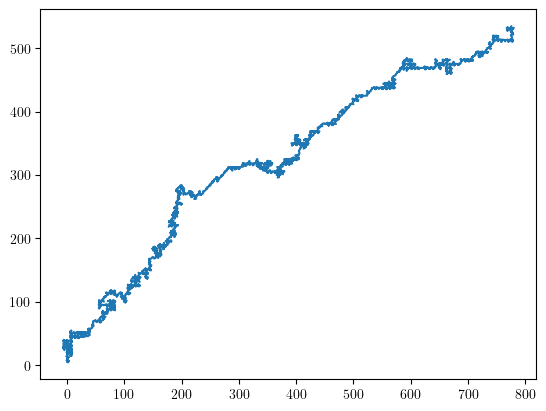

In [77]:
plt.plot(lifted[:, 0], lifted[:, 1])